In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [3]:
print("Shape of dataset:", df.shape)

Shape of dataset: (267, 9)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    str    
 1    Date                                     267 non-null    str    
 2    Frequency                                267 non-null    str    
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    str    
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 18.9 KB


In [5]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [6]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')

In [7]:
df.head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74
5,Andhra Pradesh,30-06-2020,M,3.31,19805400,47.41,South,15.9129,79.74
6,Andhra Pradesh,31-07-2020,M,8.34,15431615,38.91,South,15.9129,79.74
7,Andhra Pradesh,31-08-2020,M,6.96,15251776,37.83,South,15.9129,79.74
8,Andhra Pradesh,30-09-2020,M,6.40,15220312,37.47,South,15.9129,79.74
9,Andhra Pradesh,31-10-2020,M,6.59,15157557,37.34,South,15.9129,79.74


In [8]:
df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')

In [10]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64

In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

Region                                     0.0
Date                                       0.0
Frequency                                  0.0
Estimated Unemployment Rate (%)            0.0
Estimated Employed                         0.0
Estimated Labour Participation Rate (%)    0.0
Region.1                                   0.0
longitude                                  0.0
latitude                                   0.0
dtype: float64

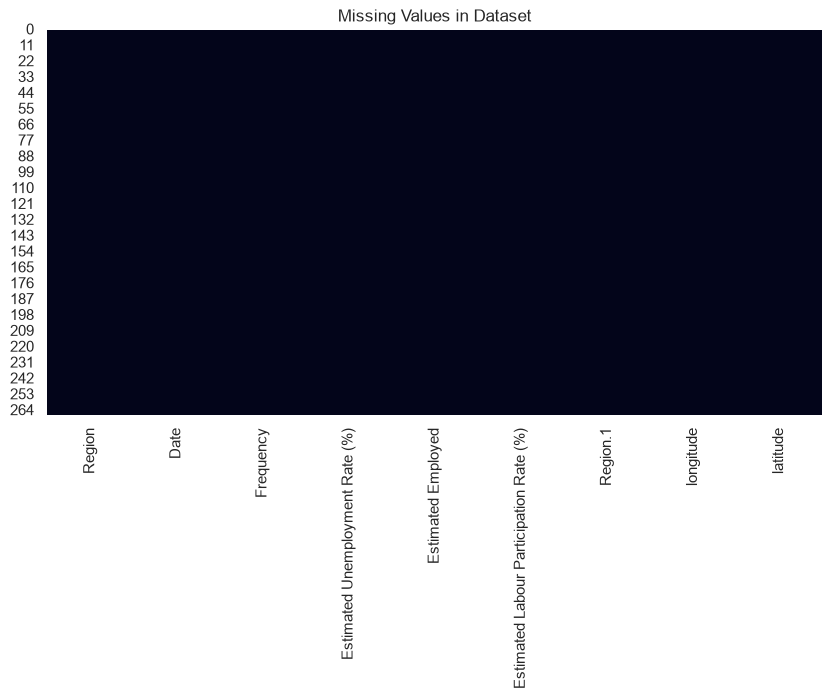

In [12]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values in Dataset")
plt.show()

In [13]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

In [14]:
df["Date"].head()

0   2020-01-31
1   2020-02-29
2   2020-03-31
3   2020-04-30
4   2020-05-31
Name: Date, dtype: datetime64[us]

In [15]:
print(df["Date"].min())
print(df["Date"].max())

2020-01-31 00:00:00
2020-10-31 00:00:00


In [16]:
print("Duplicates before:", df.duplicated().sum())

Duplicates before: 0


In [17]:
df = df.drop_duplicates()

In [18]:
print("Duplicates after:", df.duplicated().sum())

Duplicates after: 0


In [19]:
df.select_dtypes(include=np.number).columns

Index(['Estimated Unemployment Rate (%)', 'Estimated Employed',
       'Estimated Labour Participation Rate (%)', 'longitude', 'latitude'],
      dtype='str')

In [20]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

In [21]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64

In [22]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

df["Month_Name"] = df["Date"].dt.month_name()

In [23]:
df[["Date", "Year", "Month", "Month_Name"]].head()

,Date,Year,Month,Month_Name
0,2020-01-31,2020,1,January
1,2020-02-29,2020,2,February
2,2020-03-31,2020,3,March
3,2020-04-30,2020,4,April
4,2020-05-31,2020,5,May


In [24]:
monthly_unemployment = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

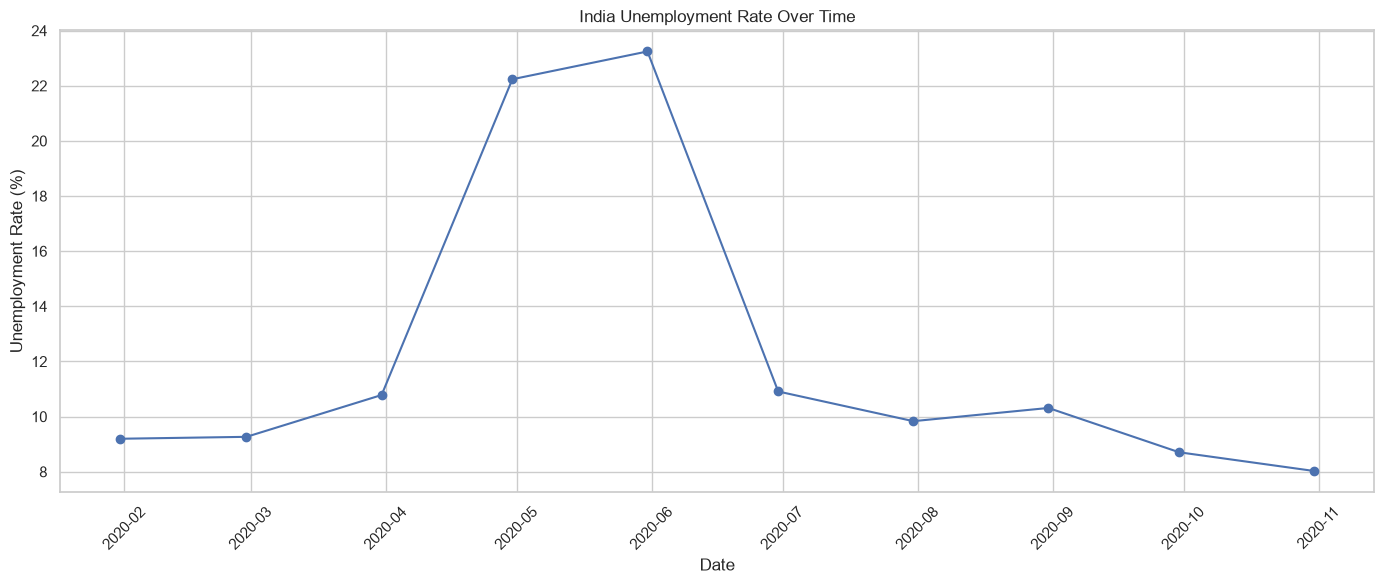

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_unemployment["Date"],
    monthly_unemployment["Estimated Unemployment Rate (%)"],
    marker="o"
)

plt.title("India Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [26]:
df["COVID_Period"] = np.where(
    df["Date"] >= "2020-03-01",
    "COVID Period",
    "Pre-COVID"
)

In [27]:
df["COVID_Period"] = np.where(
    (df["Date"] >= "2020-03-01") &
    (df["Date"] <= "2020-06-30"),
    "COVID Period",
    "Other Period"
)

In [28]:
covid_analysis = df.groupby("COVID_Period")[
    "Estimated Unemployment Rate (%)"
].mean()

covid_analysis

COVID_Period
COVID Period    16.742710
Other Period     9.223688
Name: Estimated Unemployment Rate (%), dtype: float64

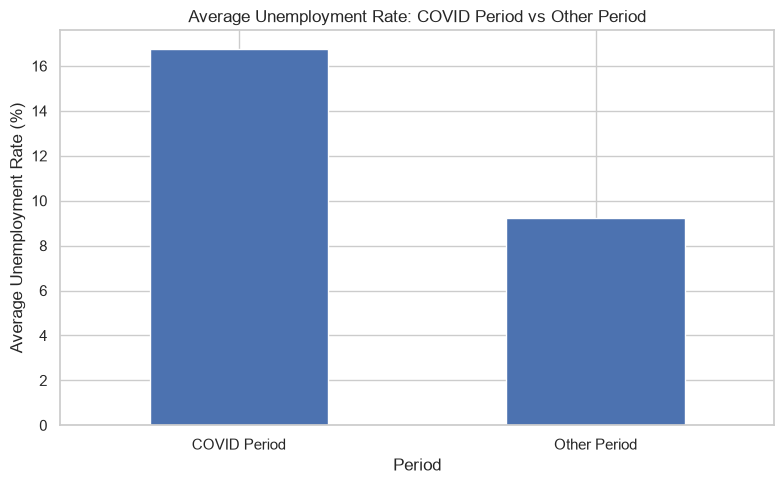

In [29]:
plt.figure(figsize=(8, 5))

covid_analysis.plot(kind="bar")

plt.title("Average Unemployment Rate: COVID Period vs Other Period")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [30]:
pre_covid = df[
    df["Date"] < "2020-03-01"
]["Estimated Unemployment Rate (%)"].mean()

covid_period = df[
    (df["Date"] >= "2020-03-01") &
    (df["Date"] <= "2020-06-30")
]["Estimated Unemployment Rate (%)"].mean()

difference = covid_period - pre_covid

print("Pre-COVID average:", round(pre_covid, 2))
print("COVID-period average:", round(covid_period, 2))
print("Difference:", round(difference, 2))

Pre-COVID average: 9.23
COVID-period average: 16.74
Difference: 7.51


In [31]:
monthly_unemployment.loc[
    monthly_unemployment[
        "Estimated Unemployment Rate (%)"
    ].idxmax()
]

Date                               2020-05-31 00:00:00
Estimated Unemployment Rate (%)              23.244444
Name: 4, dtype: object

In [32]:
monthly_unemployment.loc[
    monthly_unemployment[
        "Estimated Unemployment Rate (%)"
    ].idxmin()
]

Date                               2020-10-31 00:00:00
Estimated Unemployment Rate (%)               8.026296
Name: 9, dtype: object

In [33]:
highest_month = monthly_unemployment.loc[
    monthly_unemployment["Estimated Unemployment Rate (%)"].idxmax()
]

lowest_month = monthly_unemployment.loc[
    monthly_unemployment["Estimated Unemployment Rate (%)"].idxmin()
]

print("Highest unemployment:")
print(highest_month)

print("\nLowest unemployment:")
print(lowest_month)

Highest unemployment:
Date                               2020-05-31 00:00:00
Estimated Unemployment Rate (%)              23.244444
Name: 4, dtype: object

Lowest unemployment:
Date                               2020-10-31 00:00:00
Estimated Unemployment Rate (%)               8.026296
Name: 9, dtype: object


In [34]:
region_analysis = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

In [35]:
region_analysis

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64

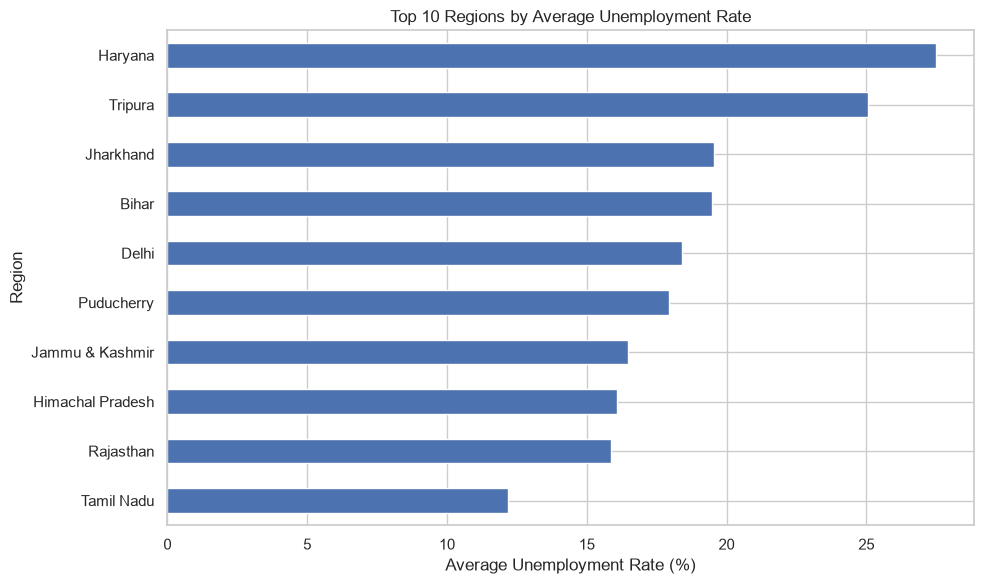

In [36]:
top_10_regions = region_analysis.head(10)

plt.figure(figsize=(10, 6))

top_10_regions.sort_values().plot(kind="barh")

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

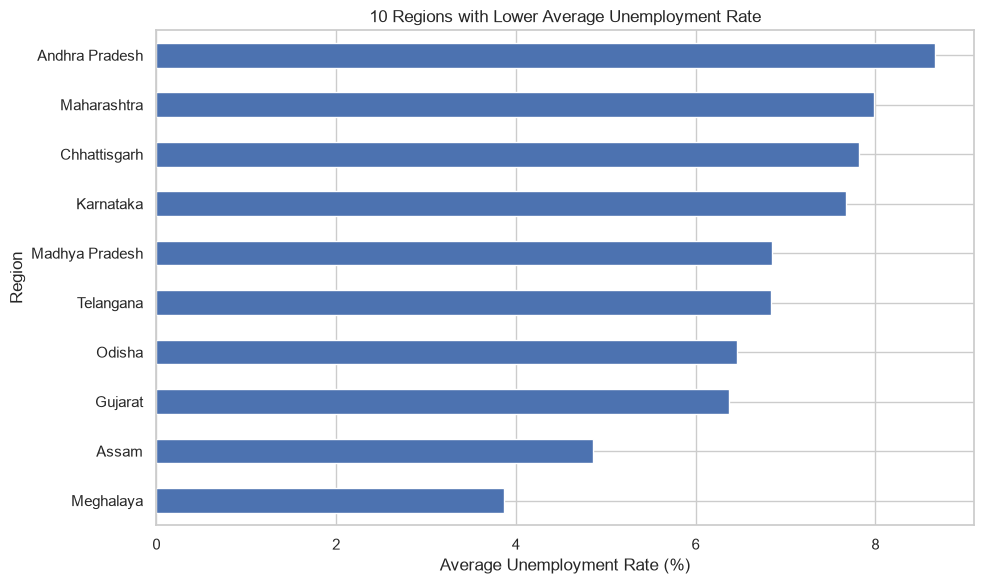

In [37]:
bottom_10_regions = region_analysis.tail(10)

plt.figure(figsize=(10, 6))

bottom_10_regions.sort_values().plot(kind="barh")

plt.title("10 Regions with Lower Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

In [39]:
monthly_seasonal = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
    .mean()
)

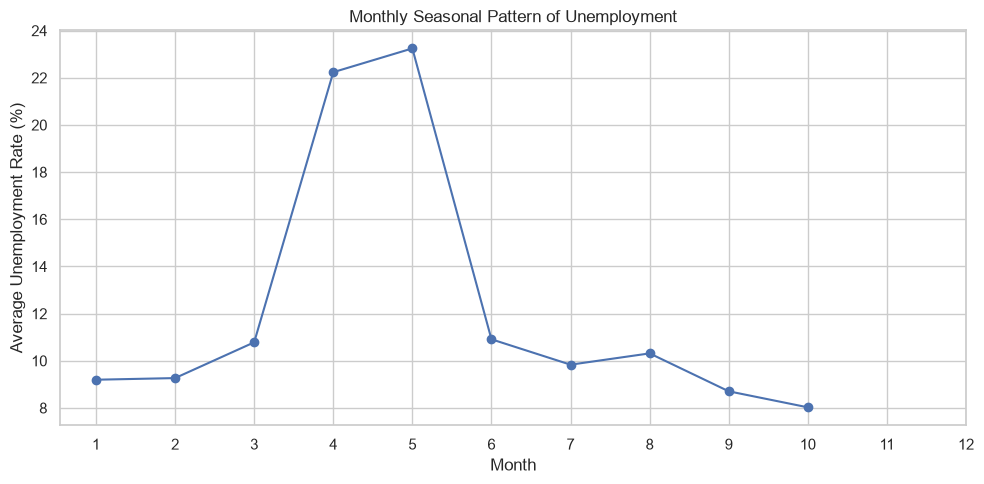

In [40]:
plt.figure(figsize=(10, 5))

monthly_seasonal.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Seasonal Pattern of Unemployment")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [41]:
year_analysis = (
    df.groupby("Year")["Estimated Unemployment Rate (%)"]
    .mean()
)

print(year_analysis)

Year
2020    12.236929
Name: Estimated Unemployment Rate (%), dtype: float64


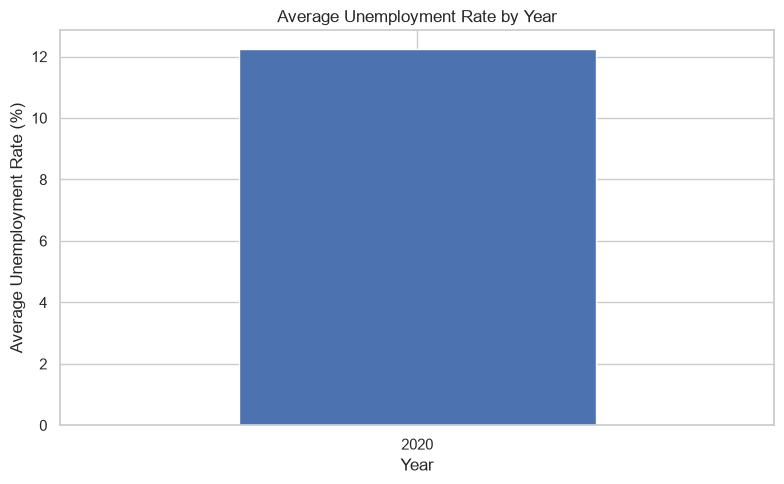

In [42]:
plt.figure(figsize=(8, 5))

year_analysis.plot(
    kind="bar"
)

plt.title("Average Unemployment Rate by Year")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

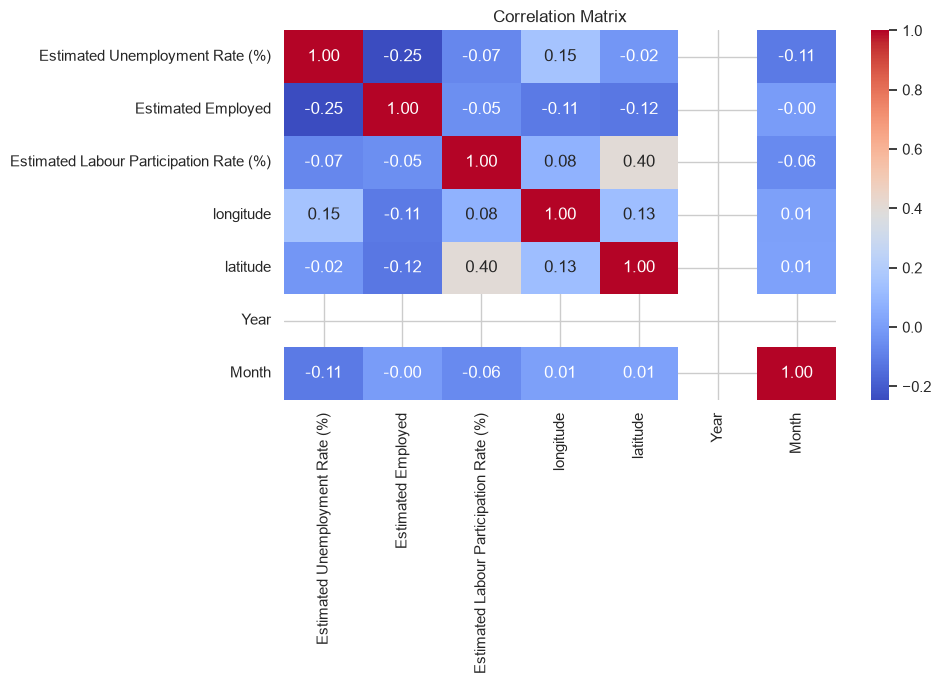

In [43]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

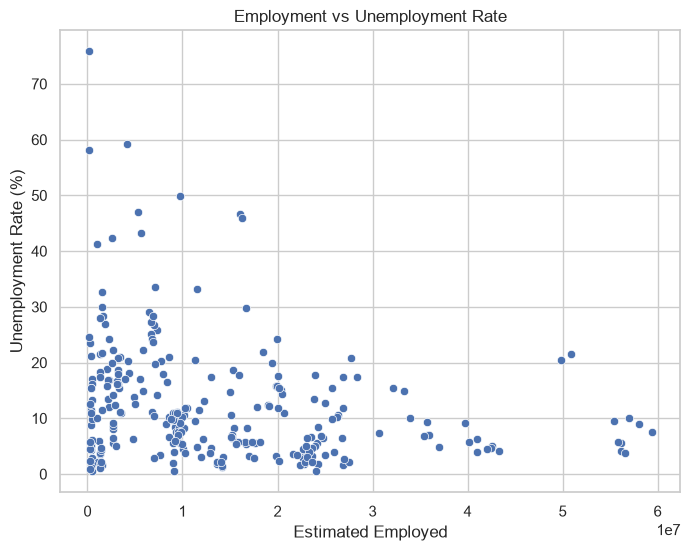

In [44]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Estimated Employed",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Employment vs Unemployment Rate")
plt.xlabel("Estimated Employed")
plt.ylabel("Unemployment Rate (%)")

plt.show()

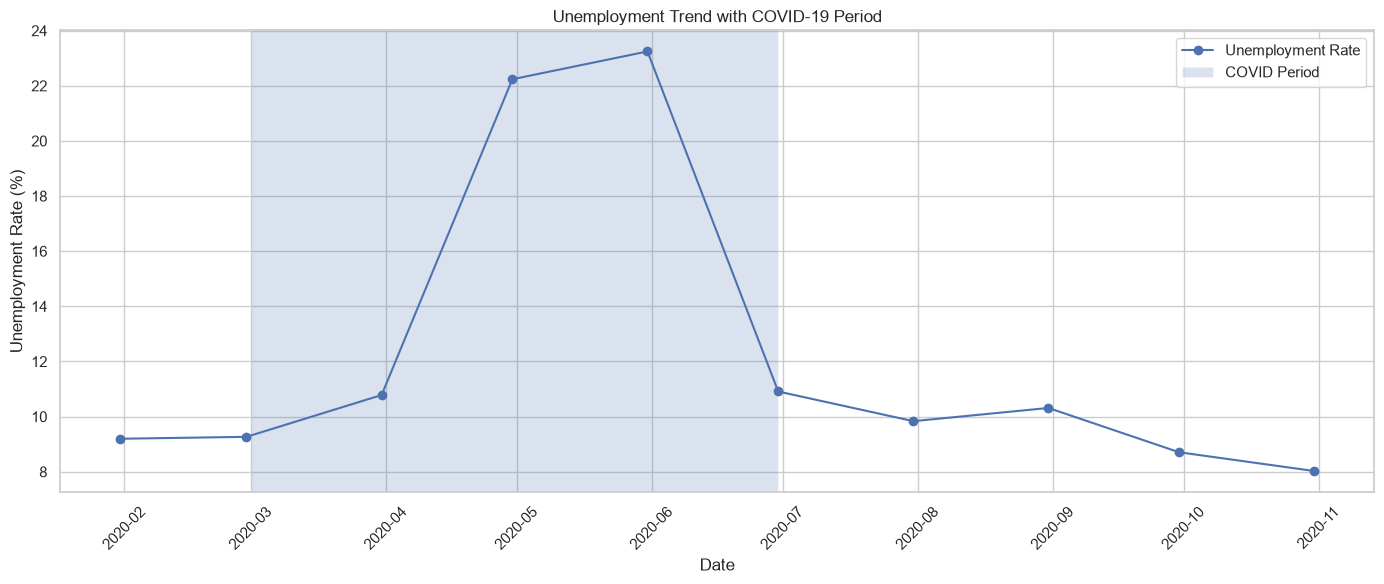

In [45]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_unemployment["Date"],
    monthly_unemployment["Estimated Unemployment Rate (%)"],
    marker="o",
    label="Unemployment Rate"
)

plt.axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2020-06-30"),
    alpha=0.2,
    label="COVID Period"
)

plt.title("Unemployment Trend with COVID-19 Period")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [46]:
summary = {
    "Overall Average Unemployment Rate":
        df["Estimated Unemployment Rate (%)"].mean(),

    "Pre-COVID Average":
        pre_covid,

    "COVID Period Average":
        covid_period,

    "COVID Difference":
        difference,

    "Highest Monthly Rate":
        monthly_unemployment[
            "Estimated Unemployment Rate (%)"
        ].max(),

    "Lowest Monthly Rate":
        monthly_unemployment[
            "Estimated Unemployment Rate (%)"
        ].min()
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Overall Average Unemployment Rate,12.236929
1,Pre-COVID Average,9.231346
2,COVID Period Average,16.742710
3,COVID Difference,7.511364
4,Highest Monthly Rate,23.244444
5,Lowest Monthly Rate,8.026296


In [47]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude,Year,Month,Month_Name,COVID_Period
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74,2020,1,January,Other Period
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74,2020,2,February,Other Period
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74,2020,3,March,COVID Period
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74,2020,4,April,COVID Period
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74,2020,5,May,COVID Period
